<a href="https://colab.research.google.com/github/SahputraS/MIGHTE-respicast-jointGBM/blob/main/LightGBM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/SahputraS/MIGHTE-respicast-jointGBM.git
%cd MIGHTE-respicast-jointGBM

Cloning into 'MIGHTE-respicast-jointGBM'...
remote: Enumerating objects: 265, done.
remote: Counting objects: 100% (265/265), done.
remote: Compressing objects: 100% (238/238), done.
remote: Total 265 (delta 131), reused 108 (delta 21), pack-reused 0 (from 0)
Receiving objects: 100% (265/265), 7.09 MiB | 8.89 MiB/s, done.
Resolving deltas: 100% (131/131), done.
/content/MIGHTE-respicast-jointGBM


In [2]:
%cd /content/MIGHTE-respicast-jointGBM
!git pull origin main

/content/MIGHTE-respicast-jointGBM
From https://github.com/SahputraS/MIGHTE-respicast-jointGBM
 * branch            main       -> FETCH_HEAD
Already up to date.


In [3]:
!pip install \
  "lightgbm>=4.3" \
  "lightgbmlss>=0.2.5"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 55.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 899.7/899.7 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 103.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 MB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 288

In [4]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 6.6 MB/s eta 0:00:00


In [5]:
# Verify the correct version
import lightgbm as lgb
import lightgbmlss
print("lightgbm:", lgb.__version__)
import importlib.metadata
print("lightgbmlss:", importlib.metadata.version("lightgbmlss"))

lightgbm: 4.6.0
lightgbmlss: 0.6.1


In [6]:
# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
import pandas as pd
import numpy as np
import optuna

## Clone the respicast data

In [8]:
!git clone --depth 1 https://github.com/european-modelling-hubs/RespiCast-SyndromicIndicators.git

Cloning into 'RespiCast-SyndromicIndicators'...
remote: Enumerating objects: 1787, done.
remote: Counting objects: 100% (1787/1787), done.
remote: Compressing objects: 100% (894/894), done.
remote: Total 1787 (delta 1170), reused 1379 (delta 889), pack-reused 0 (from 0)
Receiving objects: 100% (1787/1787), 82.71 MiB | 14.81 MiB/s, done.
Resolving deltas: 100% (1170/1170), done.
Updating files: 100% (1765/1765), done.


## Gridsearch only LGBM

In [16]:
import importlib, sys
sys.path.insert(0, "/content/MIGHTE-respicast-jointGBM/src")
import model_joint_twostage_eu
importlib.reload(model_joint_twostage_eu)
from model_joint_twostage_eu import (
    _load_target_panel, _pivot, compute_top_donors,
    build_features, build_pooled_examples, feature_columns,
)
print("import OK")

optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Config ──
DATA = "/content/MIGHTE-respicast-jointGBM/data/processed/respicast_long_latest.csv"
GT_FILE_PROCESSED   = "/content/drive/MyDrive/google data/google_trends_wide.csv"
GT_FILE_UNPROCESSED = "/content/drive/MyDrive/google data/google_trends_wide(unprocessed).csv"
TARGET = "ILI incidence"
OTHER  = "ARI incidence"

EXCLUDE_COVID = True

loc_df = pd.read_csv("/content/MIGHTE-respicast-jointGBM/RespiCast-SyndromicIndicators/supporting-files/locations_iso2_codes.csv")
LOCATIONS = sorted(loc_df["iso2_code"].astype(str).unique().tolist())

ANCHOR = pd.to_datetime("2025-05-01")

# ── Build matrix ──
def build_matrix(gt_file=None):
    target_df = _load_target_panel(DATA, TARGET, LOCATIONS,
                                   cutoff_date=ANCHOR, calendar_end_date=ANCHOR,
                                   exclude_covid=EXCLUDE_COVID)
    other_df  = _load_target_panel(DATA, OTHER,  LOCATIONS,
                                   cutoff_date=ANCHOR, calendar_end_date=ANCHOR,
                                   exclude_covid=EXCLUDE_COVID)

    tgt_pivot, oth_pivot = _pivot(target_df), _pivot(other_df)
    donor_same  = compute_top_donors(tgt_pivot, tgt_pivot, 4, 30, "delta_log")
    donor_other = compute_top_donors(tgt_pivot, oth_pivot, 2, 30, "delta_log")

    gt_df = pd.read_csv(gt_file, parse_dates=["date"]) if gt_file is not None else None

    feat = build_features(
        target_df, other_df,
        own_lags=[1,2,3,4,5,6,7,8,9,10,11,12,26,52],
        donor_lags=[1,2,3,4,8,12],
        same_target_donors=donor_same, other_target_donors=donor_other,
        donor_top_k=4, other_top_k=2, gt_df=gt_df,
    )
    pooled = build_pooled_examples(feat, 4)
    feat_cols = feature_columns(pooled)

    df = pooled.dropna(subset=["target"]).copy()
    y_log = np.log1p(np.clip(df["target"].to_numpy(float), 0, None))
    base  = np.log1p(np.clip(df["y_base"].to_numpy(float), 0, None))
    y = y_log - base
    ok = np.isfinite(y)
    df, y = df.loc[ok].reset_index(drop=True), y[ok]
    return df, y, feat_cols

# ── RMSE for a given param set ──
def rmse_for_config(df, y, feat_cols, params):
    cut = df["date"].quantile(0.75)
    tr = (df["date"] <= cut).to_numpy()
    X_tr, y_tr = df.loc[tr, feat_cols].astype(float), y[tr]
    X_va       = df.loc[~tr, feat_cols].astype(float)
    y_va       = y[~tr]

    p1 = {
        "objective": "regression", "metric": "l2",
        "learning_rate": params["learning_rate"],
        "num_leaves": params["num_leaves"],
        "min_child_samples": params["min_child_samples"],
        "feature_fraction": params["feature_fraction"],
        "bagging_fraction": 0.9, "bagging_freq": 1,
        "seed": 2026, "deterministic": True, "force_row_wise": True,   # ← aligned to sampler seed
        "verbosity": -1,
    }
    d_tr = lgb.Dataset(X_tr, label=y_tr)
    d_va = lgb.Dataset(X_va, label=y_va, reference=d_tr)
    model = lgb.train(
        p1, d_tr,
        num_boost_round=1000,
        valid_sets=[d_va],
        callbacks=[lgb.early_stopping(50, verbose=False)],
    )
    pred_dlog = model.predict(X_va, num_iteration=model.best_iteration)
    base_va = np.log1p(np.clip(df.loc[~tr, "y_base"].to_numpy(float), 0, None))
    pred_cases = np.maximum(np.expm1(pred_dlog + base_va), 0.0)
    actual_cases = df.loc[~tr, "target"].to_numpy(float)
    rmse = float(np.sqrt(np.mean((pred_cases - actual_cases) ** 2)))
    return rmse, int(model.best_iteration)   # ← now returns the tuple the objective unpacks

# ── Build the three matrices once ──
print("Building feature matrices...")
df_nogt,   y_nogt,   cols_nogt   = build_matrix(gt_file=None)
df_proc,   y_proc,   cols_proc   = build_matrix(gt_file=GT_FILE_PROCESSED)
df_unproc, y_unproc, cols_unproc = build_matrix(gt_file=GT_FILE_UNPROCESSED)
print(f"  no-GT:                {df_nogt.shape[0]} rows, {len(cols_nogt)} features")
print(f"  GT denoised+detrend:  {df_proc.shape[0]} rows, {len(cols_proc)} features")
print(f"  GT raw:               {df_unproc.shape[0]} rows, {len(cols_unproc)} features\n")

# ── Optuna objective factory ──
def make_objective(df, y, feat_cols):
    def objective(trial):
        params = {
            "num_leaves":        trial.suggest_int("num_leaves", 50, 130),
            "learning_rate":     trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
            "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
            "feature_fraction":  trial.suggest_float("feature_fraction", 0.6, 1.0),
        }                                  # ← 'rounds' removed
        rmse, best_round = rmse_for_config(df, y, feat_cols, params)
        trial.set_user_attr("best_round", best_round)   # ← capture the real number
        return rmse
    return objective

N_TRIALS = 70

def run_study(name, df, y, cols):
    print(f"=== Optimizing: {name} ===")
    study = optuna.create_study(direction="minimize",
                                sampler=optuna.samplers.TPESampler(seed=1234))
    study.optimize(make_objective(df, y, cols), n_trials=N_TRIALS, show_progress_bar=True)
    print()
    return study

study_nogt   = run_study("NO Google Trends",      df_nogt,   y_nogt,   cols_nogt)
study_proc   = run_study("GT denoised+detrended", df_proc,   y_proc,   cols_proc)
study_unproc = run_study("GT raw (unprocessed)",  df_unproc, y_unproc, cols_unproc)

# ── Results ──
print("\n" + "="*60)
print("="*60)

base = study_nogt.best_value
for name, study in [("No GT",               study_nogt),
                    ("GT denoised+detrend", study_proc),
                    ("GT raw",              study_unproc)]:
    rmse_val = study.best_value
    delta = base - rmse_val
    pct = 100 * delta / base
    print(f"\n{name:20s}  RMSE = {rmse_val:.2f}   Δ vs no-GT = {delta:+.2f} ({pct:+.1f}%)")
    print(f"  params: {study.best_params}")

import OK
Building feature matrices...
  no-GT:                34875 rows, 105 features
  GT denoised+detrend:  34875 rows, 258 features
  GT raw:               34875 rows, 258 features

=== Optimizing: NO Google Trends ===


  0%|          | 0/70 [00:00<?, ?it/s]


=== Optimizing: GT denoised+detrended ===


  0%|          | 0/70 [00:00<?, ?it/s]


=== Optimizing: GT raw (unprocessed) ===


  0%|          | 0/70 [00:00<?, ?it/s]




No GT                 RMSE = 673.33   Δ vs no-GT = +0.00 (+0.0%)
  params: {'num_leaves': 105, 'learning_rate': 0.02219274311667552, 'min_child_samples': 16, 'feature_fraction': 0.9620844439251751}

GT denoised+detrend   RMSE = 659.65   Δ vs no-GT = +13.67 (+2.0%)
  params: {'num_leaves': 100, 'learning_rate': 0.021398823168362377, 'min_child_samples': 11, 'feature_fraction': 0.9661336955091331}

GT raw                RMSE = 696.41   Δ vs no-GT = -23.08 (-3.4%)
  params: {'num_leaves': 80, 'learning_rate': 0.03552826012834453, 'min_child_samples': 13, 'feature_fraction': 0.7631186453207142}


In [17]:
best = {
    "no_gt":   {**study_nogt.best_params,   "rounds": study_nogt.best_trial.user_attrs["best_round"]},
    "gt_proc": {**study_proc.best_params,   "rounds": study_proc.best_trial.user_attrs["best_round"]},
    "gt_raw":  {**study_unproc.best_params, "rounds": study_unproc.best_trial.user_attrs["best_round"]},
}
print(best)

{'no_gt': {'num_leaves': 105, 'learning_rate': 0.02219274311667552, 'min_child_samples': 16, 'feature_fraction': 0.9620844439251751, 'rounds': 74}, 'gt_proc': {'num_leaves': 100, 'learning_rate': 0.021398823168362377, 'min_child_samples': 11, 'feature_fraction': 0.9661336955091331, 'rounds': 152}, 'gt_raw': {'num_leaves': 80, 'learning_rate': 0.03552826012834453, 'min_child_samples': 13, 'feature_fraction': 0.7631186453207142, 'rounds': 195}}


In [18]:
# ── Diagnostic: per-horizon & per-country RMSE, at cutoff 0.75 ──
# Reuses matrices + best params already in memory.
best_configs = {
    "No GT":               (df_nogt,   y_nogt,   cols_nogt,   best["no_gt"]),
    "GT denoised+detrend": (df_proc,   y_proc,   cols_proc,   best["gt_proc"]),
    "GT raw":              (df_unproc, y_unproc, cols_unproc, best["gt_raw"]),
}

CUTOFFS = [0.75]

def rmse(errs):
    """RMSE from a series/array of (pred - actual) errors."""
    e = np.asarray(errs, dtype=float)
    return float(np.sqrt(np.mean(e ** 2)))

def predict_validation(df, y, feat_cols, params, cutoff_q):
    """Train stage 1 on earliest cutoff_q, predict validation. Returns a df with
    actual, pred, horizon, location, and squared error for the validation rows."""
    cut = df["date"].quantile(cutoff_q)
    tr = (df["date"] <= cut).to_numpy()

    X_tr, y_tr = df.loc[tr, feat_cols].astype(float), y[tr]
    va = df.loc[~tr].copy()
    X_va = va[feat_cols].astype(float)

    p1 = {
        "objective": "regression", "metric": "l2",
        "learning_rate": params["learning_rate"],
        "num_leaves": params["num_leaves"],
        "min_child_samples": params["min_child_samples"],
        "feature_fraction": params["feature_fraction"],
        "bagging_fraction": 0.9, "bagging_freq": 1, "verbosity": -1,
    }
    model = lgb.train(p1, lgb.Dataset(X_tr, label=y_tr), num_boost_round=params["rounds"])

    pred_dlog = model.predict(X_va)
    base_va = np.log1p(np.clip(va["y_base"].to_numpy(float), 0, None))
    va["pred"]   = np.maximum(np.expm1(pred_dlog + base_va), 0.0)
    va["actual"] = va["target"].astype(float)
    va["err"]    = va["pred"] - va["actual"]          # signed error (for RMSE)
    va["sq_err"] = va["err"] ** 2                      # squared error
    return va[["location", "horizon", "actual", "pred", "err", "sq_err"]]

# Collect predictions for every config × cutoff
all_preds = {}
for cutoff in CUTOFFS:
    for name, (df_v, y_v, cols_v, params) in best_configs.items():
        all_preds[(name, cutoff)] = predict_validation(df_v, y_v, cols_v, params, cutoff)

# 1. OVERALL RMSE per config per cutoff
print("="*70)
print("OVERALL RMSE")
print("="*70)
print(f"{'Config':22s}" + "".join(f"  {'cut='+str(c):>10s}" for c in CUTOFFS))
print("-"*(22 + 12*len(CUTOFFS)))
for name in best_configs:
    row = f"{name:22s}"
    for cutoff in CUTOFFS:
        r = rmse(all_preds[(name, cutoff)]["err"])
        row += f"  {r:10.2f}"
    print(row)

# 2. PER-HORIZON RMSE  (does GT help at longer horizons?)
for cutoff in CUTOFFS:
    print("\n" + "="*70)
    print(f"PER-HORIZON RMSE  (cutoff={cutoff})")
    print("="*70)
    horizons = sorted(all_preds[("No GT", cutoff)]["horizon"].unique())
    print(f"{'Config':22s}" + "".join(f"  {'h'+str(int(h)):>8s}" for h in horizons))
    print("-" * (22 + 10*len(horizons)))
    for name in best_configs:
        vp = all_preds[(name, cutoff)]
        row = f"{name:22s}"
        for h in horizons:
            r_h = rmse(vp[vp["horizon"] == h]["err"])
            row += f"  {r_h:8.2f}"
        print(row)

# 3. PER-COUNTRY RMSE  (best GT variant vs No-GT; negative Δ = GT helps)
for cutoff in CUTOFFS:
    # Auto-pick the best GT variant = lowest overall RMSE among the GT configs
    gt_configs = [n for n in best_configs if n != "No GT"]
    overall_rmse = {n: rmse(all_preds[(n, cutoff)]["err"]) for n in gt_configs}
    best_gt = min(overall_rmse, key=overall_rmse.get)

    print("\n" + "="*70)
    print(f"PER-COUNTRY: {best_gt} vs No-GT  (cutoff={cutoff})")
    print(f"(best GT variant by overall RMSE = {overall_rmse[best_gt]:.2f})")
    print("negative Δ = GT helps that country")
    print("="*70)

    nogt = all_preds[("No GT", cutoff)].groupby("location")["err"].apply(rmse)
    gt   = all_preds[(best_gt,  cutoff)].groupby("location")["err"].apply(rmse)
    comp = pd.DataFrame({"No_GT": nogt, "GT": gt})
    comp["delta"] = comp["GT"] - comp["No_GT"]
    comp = comp.sort_values("delta")  # most-helped first

    print(f"{'Country':10s}  {'No_GT':>9s}  {'GT':>9s}  {'Δ':>9s}")
    print("-"*42)
    for loc, r in comp.iterrows():
        flag = "  ✓ GT helps" if r["delta"] < -0.5 else ("  ✗ GT hurts" if r["delta"] > 0.5 else "")
        print(f"{loc:10s}  {r['No_GT']:9.1f}  {r['GT']:9.1f}  {r['delta']:+9.2f}{flag}")

    n_helped = (comp["delta"] < -0.5).sum()
    n_hurt   = (comp["delta"] > 0.5).sum()
    n_neutral = len(comp) - n_helped - n_hurt
    print(f"\nSummary: {best_gt} helps {n_helped}, hurts {n_hurt}, neutral {n_neutral} (of {len(comp)} countries)")

OVERALL RMSE
Config                    cut=0.75
----------------------------------
No GT                       702.23
GT denoised+detrend         682.08
GT raw                      760.61

PER-HORIZON RMSE  (cutoff=0.75)
Config                        h1        h2        h3        h4
--------------------------------------------------------------
No GT                     633.50    648.81    735.58    783.42
GT denoised+detrend       617.43    673.79    676.15    756.31
GT raw                    665.37    715.55    774.02    875.61

PER-COUNTRY: GT denoised+detrend vs No-GT  (cutoff=0.75)
(best GT variant by overall RMSE = 682.08)
negative Δ = GT helps that country
Country         No_GT         GT          Δ
------------------------------------------
LU             3058.7     2631.3    -427.43  ✓ GT helps
IT              251.4      202.4     -48.95  ✓ GT helps
GR              325.4      287.2     -38.18  ✓ GT helps
IE               33.4       11.6     -21.77  ✓ GT helps
HU              1

In [32]:
def learning_curve_diagnosis(matrices, params_by, cutoff_q=0.75,
                             configs_to_plot=("No GT", "GT raw"),
                             max_rounds=500):
    colors = {"No GT": "#377EB8", "GT raw": "#E41A1C", "GT denoised+detrend": "#4DAF4A"}
    plt.figure(figsize=(10, 6))
    importances = {}
    best_rounds = {}                              # ← NEW

    for name in configs_to_plot:
        df, y, feat_cols = matrices[name]
        params = params_by[name]
        color = colors.get(name, "#333333")

        cut = df["date"].quantile(cutoff_q)
        tr = (df["date"] <= cut).to_numpy()
        X_tr, y_tr = df.loc[tr, feat_cols].astype(float), y[tr]
        X_va, y_va = df.loc[~tr, feat_cols].astype(float), y[~tr]

        p1 = {
            "objective": "regression", "metric": "l2",
            "learning_rate": params["learning_rate"],
            "num_leaves": params["num_leaves"],
            "min_child_samples": params["min_child_samples"],
            "feature_fraction": params["feature_fraction"],
            "bagging_fraction": 0.9, "bagging_freq": 1,
            "seed": 2026, "deterministic": True, "force_row_wise": True,   # ← seed for stable argmin
            "verbosity": -1,
        }
        d_tr = lgb.Dataset(X_tr, label=y_tr)
        d_va = lgb.Dataset(X_va, label=y_va, reference=d_tr)
        evals = {}
        model = lgb.train(p1, d_tr, num_boost_round=max_rounds,
                          valid_sets=[d_tr, d_va], valid_names=["train", "valid"],
                          callbacks=[lgb.record_evaluation(evals)])

        plt.plot(evals["train"]["l2"], color=color, linestyle="-",  label=f"{name} train")
        plt.plot(evals["valid"]["l2"], color=color, linestyle="--", label=f"{name} valid")

        best_round = int(np.argmin(evals["valid"]["l2"])) + 1   # ← +1: argmin is 0-indexed
        best_loss  = evals["valid"]["l2"][best_round - 1]
        best_rounds[name] = best_round                          # ← NEW: keep it
        print(f"{name:22s}  best valid round = {best_round:3d} (loss {best_loss:.5f})")

        imp = pd.DataFrame({
            "feature": model.feature_name(),
            "gain": model.feature_importance(importance_type="gain"),
        }).sort_values("gain", ascending=False)
        importances[name] = imp

    plt.xlabel("Boosting round (Stage 1)")
    plt.ylabel("L2 loss (log-change space)")
    plt.title(f"Stage 1 learning curves (cutoff={cutoff_q})")
    plt.legend(fontsize=9); plt.tight_layout()
    plt.savefig("learning_curve_diagnosis.png", dpi=150, bbox_inches="tight"); plt.show()

    return importances, best_rounds

In [35]:
matrices = {
    "No GT":               (df_nogt,   y_nogt,   cols_nogt),
    "GT denoised+detrend": (df_proc,   y_proc,   cols_proc),
    "GT raw":              (df_unproc, y_unproc, cols_unproc),
}
params_by = {
    "No GT":               study_nogt.best_params,
    "GT denoised+detrend": study_proc.best_params,
    "GT raw":              study_unproc.best_params,
}


No GT                   best valid round =  74 (loss 0.33451)
GT denoised+detrend     best valid round = 152 (loss 0.31129)
GT raw                  best valid round = 195 (loss 0.30022)


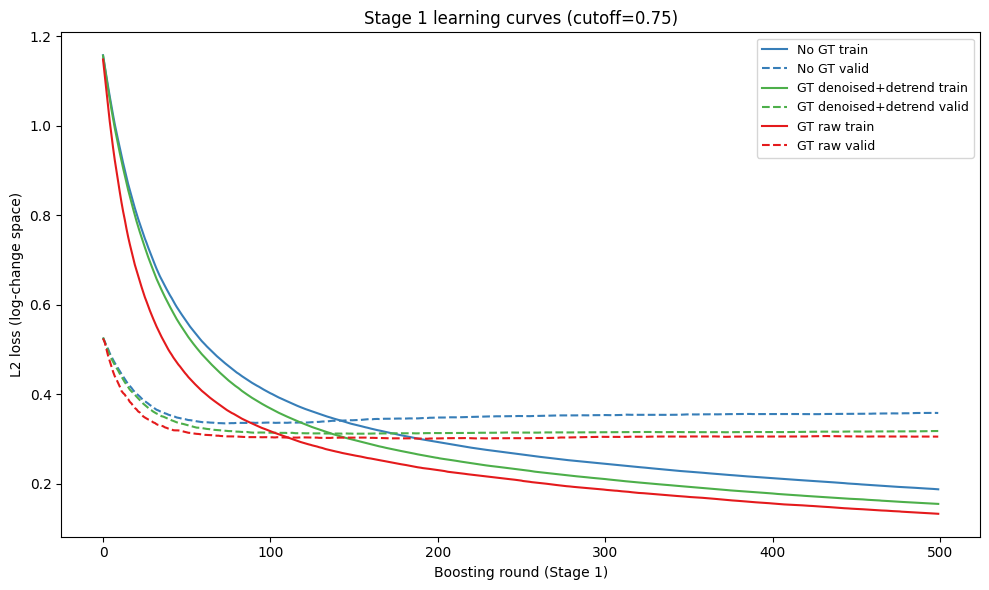


TOP 25 FEATURES — GT denoised+detrend
rank  feature                                      gain  type
-----------------------------------------------------------------
   1  week_sin                                  79254.7  
   2  y_pct_chg_1                               41871.6  
   3  y_lag_1                                   33450.0  
   4  horizon                                   26680.1  
   5  week_cos                                  20300.2  
   6  y_diff_1                                  18922.6  
   7  y_lag_26                                  17301.3  
   8  y_lag_52                                   9859.6  
   9  y_diff_4                                   8623.2  
  10  donor_tgt_1_lag_1                          7730.4  
  11  other_loc_lag_8                            7300.1  
  12  loc_LU                                     7053.4  
  13  donor_tgt_2_lag_8                          6283.3  
  14  cough_lag3                                 5836.0  GT
  15  other_loc_lag

In [36]:
# Run the learning curve + get feature importances
importances, best_rounds  = learning_curve_diagnosis(
    matrices, params_by,
    cutoff_q=0.75,
    configs_to_plot=("No GT", "GT denoised+detrend", "GT raw"),   # compare baseline vs best GT
    max_rounds=500,
)

# Show which features the GT model actually used
show_gt_feature_importance(importances, gt_config="GT denoised+detrend", top_n=25)
show_gt_feature_importance(importances, gt_config="GT raw", top_n=25)

In [42]:
NAME_TO_KEY = {"No GT": "no_gt", "GT denoised+detrend": "gt_proc", "GT raw": "gt_raw"}
best = {key: {**params_by[name], "rounds": best_rounds[name]}
        for name, key in NAME_TO_KEY.items()}
print({k: v["rounds"] for k, v in best.items()})
best

{'no_gt': 74, 'gt_proc': 152, 'gt_raw': 195}


{'no_gt': {'num_leaves': 105,
  'learning_rate': 0.02219274311667552,
  'min_child_samples': 16,
  'feature_fraction': 0.9620844439251751,
  'rounds': 74},
 'gt_proc': {'num_leaves': 100,
  'learning_rate': 0.021398823168362377,
  'min_child_samples': 11,
  'feature_fraction': 0.9661336955091331,
  'rounds': 152},
 'gt_raw': {'num_leaves': 80,
  'learning_rate': 0.03552826012834453,
  'min_child_samples': 13,
  'feature_fraction': 0.7631186453207142,
  'rounds': 195}}

In [44]:
from model_joint_twostage_eu import fit_two_stage_one_bag, predict_quantiles, QUANTILES

SEED = 1234

# ── WIS (mirrors compute_wis() in eval_backtest.R) ──
def wis_vectorized(pred_q, truth, quantiles):
    q = np.asarray(quantiles, float); o = np.argsort(q); q, pred_q = q[o], pred_q[:, o]
    median = pred_q[:, int(np.argmin(np.abs(q - 0.5)))]
    interval_sum = np.zeros(len(truth)); k = 0
    for lp in q[q < 0.5]:
        li = int(np.argmin(np.abs(q - lp))); ui = int(np.argmin(np.abs(q - (1 - lp))))
        lq, uq = pred_q[:, li], pred_q[:, ui]; alpha = 2 * lp
        is_alpha = ((uq - lq)
                    + (2/alpha) * (lq - truth) * (truth < lq)
                    + (2/alpha) * (truth - uq) * (truth > uq))
        interval_sum += (alpha/2) * is_alpha; k += 1
    return (0.5 * np.abs(truth - median) + interval_sum) / (k + 0.5)

# ── Stage-1 rounds = argmin of the validation L2 curve (same logic as the learning-curve plot) ──
def best_valid_round(df, y, feat_cols, s1, cutoff_q=0.75, ceiling=500, seed=SEED):
    cut = df["date"].quantile(cutoff_q); tr = (df["date"] <= cut).to_numpy()
    X_tr, y_tr = df.loc[tr, feat_cols].astype(float), y[tr]
    X_va, y_va = df.loc[~tr, feat_cols].astype(float), y[~tr]
    p1 = {
        "objective": "regression", "metric": "l2",
        "learning_rate": s1["learning_rate"], "num_leaves": s1["num_leaves"],
        "min_child_samples": s1["min_child_samples"], "feature_fraction": s1["feature_fraction"],
        "bagging_fraction": 0.9, "bagging_freq": 1,
        "seed": seed, "deterministic": True, "force_row_wise": True, "verbosity": -1,
    }
    evals = {}
    lgb.train(p1, lgb.Dataset(X_tr, label=y_tr), num_boost_round=ceiling,
              valid_sets=[lgb.Dataset(X_va, label=y_va)], valid_names=["valid"],
              callbacks=[lgb.record_evaluation(evals)])
    return int(np.argmin(evals["valid"]["l2"])) + 1   # +1: argmin is 0-indexed, rounds are 1-indexed

# ── Stage-2 WIS tuner (uses the rounds passed in; does NOT recompute) ──
def tune_stage2(df, y, feat_cols, stage1_params, n_trials=60, cutoff_q=0.75, seed=SEED):
    s1 = dict(stage1_params)
    cut = df["date"].quantile(cutoff_q); tr = (df["date"] <= cut).to_numpy(); va = ~tr
    X_tr, y_tr = df.loc[tr, feat_cols].astype(float), y[tr]
    X_va       = df.loc[va, feat_cols].astype(float)
    base_va = df.loc[va, "y_base"].to_numpy(float)
    actual  = df.loc[va, "target"].to_numpy(float); ok = np.isfinite(actual)

    print(f"stage-1 rounds (frozen) = {s1['rounds']}")

    def objective(trial):
        stage1, stage2 = fit_two_stage_one_bag(
            X_train=X_tr, y_train=y_tr,
            stage1_rounds=s1["rounds"], seed=seed,
            num_leaves=s1["num_leaves"], learning_rate=s1["learning_rate"],
            min_child_samples=s1["min_child_samples"], feature_fraction=s1["feature_fraction"],
            stage2_rounds=trial.suggest_int("stage2_rounds", 30, 250),
            sigma_mode="bounded",
            lambda_l2=trial.suggest_float("lambda_l2", 1e-3, 5.0, log=True),
            s2_min_child_samples=trial.suggest_int("s2_min_child_samples", 10, 120),
            s2_num_leaves=None, s2_learning_rate=None, s2_feature_fraction=None, s2_max_depth=6,
        )
        pred_q = predict_quantiles(stage1, stage2, X_va, QUANTILES,
                                   target_mode="delta_log", current_obs=base_va)
        pred_q = np.clip(np.nan_to_num(pred_q, nan=0.0, posinf=1e7, neginf=0.0), 0.0, 1e7)
        score = float(np.mean(wis_vectorized(pred_q[ok], actual[ok], QUANTILES)))
        return score if np.isfinite(score) else 1e12

    study = optuna.create_study(direction="minimize",
                                sampler=optuna.samplers.TPESampler(seed=seed))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    study.set_user_attr("stage1_rounds", s1["rounds"])
    print(f"best WIS = {study.best_value:.4f}\nparams = {study.best_params}\n")
    return study

In [45]:
study_s2_nogt   = tune_stage2(df_nogt,   y_nogt,   cols_nogt,   best["no_gt"])

stage-1 rounds (frozen) = 74


  0%|          | 0/60 [00:00<?, ?it/s]

best WIS = 120.5936
params = {'stage2_rounds': 200, 'lambda_l2': 1.8401926373767212, 's2_min_child_samples': 50}



In [46]:
study_s2_proc   = tune_stage2(df_proc,   y_proc,   cols_proc,   best["gt_proc"])

stage-1 rounds (frozen) = 152


  0%|          | 0/60 [00:00<?, ?it/s]

best WIS = 118.5339
params = {'stage2_rounds': 166, 'lambda_l2': 0.0019003471843447599, 's2_min_child_samples': 50}



In [47]:
study_s2_unproc = tune_stage2(df_unproc, y_unproc, cols_unproc, best["gt_raw"])

stage-1 rounds (frozen) = 195


  0%|          | 0/60 [00:00<?, ?it/s]

best WIS = 127.1008
params = {'stage2_rounds': 128, 'lambda_l2': 1.0964972816211596, 's2_min_child_samples': 90}



# Save best params

In [49]:
# import os, json

# GDRIVE_PARAMS = "/content/drive/MyDrive/google data/best_params_ablation.json"

# def pack(study_s1, study_s2):
#     """Combine stage-1 search params + early-stopped rounds + stage-2 WIS params into one dict."""
#     return {
#         # ── stage 1 (point forecast) ──
#         **study_s1.best_params,                                  # num_leaves, learning_rate, etc.
#         "rounds": study_s1.best_trial.user_attrs["best_round"],  # early-stopped stage-1 rounds
#         # ── stage 2 (spread) ──
#         "stage1_rounds_for_s2": study_s2.user_attrs["stage1_rounds"],  # rounds frozen during WIS tuning
#         **{f"s2_{k}" if not k.startswith(("stage2", "lambda", "sigma", "s2")) else k: v
#            for k, v in study_s2.best_params.items()},
#     }

# best = {
#     "no_gt":   pack(study_nogt,   study_s2_nogt),
#     "gt_proc": pack(study_proc,   study_s2_proc),
#     "gt_raw":  pack(study_unproc, study_s2_unproc),
# }

# os.makedirs(os.path.dirname(GDRIVE_PARAMS), exist_ok=True)
# with open(GDRIVE_PARAMS, "w") as f:
#     json.dump(best, f, indent=2)

# print(f"Saved best params to {GDRIVE_PARAMS}")
# print(json.dumps(best, indent=2))

Saved best params to /content/drive/MyDrive/google data/best_params_ablation.json
{
  "no_gt": {
    "num_leaves": 105,
    "learning_rate": 0.02219274311667552,
    "min_child_samples": 16,
    "feature_fraction": 0.9620844439251751,
    "rounds": 74,
    "stage1_rounds_for_s2": 74,
    "stage2_rounds": 200,
    "lambda_l2": 1.8401926373767212,
    "s2_min_child_samples": 50
  },
  "gt_proc": {
    "num_leaves": 100,
    "learning_rate": 0.021398823168362377,
    "min_child_samples": 11,
    "feature_fraction": 0.9661336955091331,
    "rounds": 152,
    "stage1_rounds_for_s2": 152,
    "stage2_rounds": 166,
    "lambda_l2": 0.0019003471843447599,
    "s2_min_child_samples": 50
  },
  "gt_raw": {
    "num_leaves": 80,
    "learning_rate": 0.03552826012834453,
    "min_child_samples": 13,
    "feature_fraction": 0.7631186453207142,
    "rounds": 195,
    "stage1_rounds_for_s2": 195,
    "stage2_rounds": 128,
    "lambda_l2": 1.0964972816211596,
    "s2_min_child_samples": 90
  }
}


In [43]:
# import os, json

# # ── Save best params to Google Drive ──
# GDRIVE_PARAMS = "/content/drive/MyDrive/google data/best_params_ablation.json"

# os.makedirs(os.path.dirname(GDRIVE_PARAMS), exist_ok=True)

# with open(GDRIVE_PARAMS, "w") as f:
#     json.dump(best, f, indent=2)

# print(f"Saved best params to {GDRIVE_PARAMS}")
# print(json.dumps(best, indent=2))

Saved best params to /content/drive/MyDrive/google data/best_params_ablation.json
{
  "no_gt": {
    "num_leaves": 105,
    "learning_rate": 0.02219274311667552,
    "min_child_samples": 16,
    "feature_fraction": 0.9620844439251751,
    "rounds": 74
  },
  "gt_proc": {
    "num_leaves": 100,
    "learning_rate": 0.021398823168362377,
    "min_child_samples": 11,
    "feature_fraction": 0.9661336955091331,
    "rounds": 152
  },
  "gt_raw": {
    "num_leaves": 80,
    "learning_rate": 0.03552826012834453,
    "min_child_samples": 13,
    "feature_fraction": 0.7631186453207142,
    "rounds": 195
  }
}


## Run Original

In [ ]:
# ── Unpack best params for no-GT run (old single-stage search) ──
NUM_LEAVES        = best['no_gt']['num_leaves']
LEARNING_RATE     = best['no_gt']['learning_rate']
MIN_CHILD_SAMPLES = best['no_gt']['min_child_samples']
FEATURE_FRACTION  = best['no_gt']['feature_fraction']
STAGE1_ROUNDS     = best['no_gt']['rounds']   # route tuned rounds → stage 1
STAGE2_ROUNDS     = 93                       # repo default for the spread stage

START_ORIGIN = pd.Timestamp.fromisocalendar(2025, 40, 7).date().isoformat()  # Sunday of ISO week 40, 2025

!cd /content/MIGHTE-respicast-jointGBM && python src/forecast_backtest.py \
  --hub-dir /content/MIGHTE-respicast-jointGBM/RespiCast-SyndromicIndicators \
  --targets "ILI" \
  --start-origin-date "$START_ORIGIN" \
  --submission-dir /content/output/MIGHTE-ISI_lgbm \
  --num-bags 5 \
  --location-bag-frac 0.8 \
  --canonical-data /content/data/respicast_long_latest.csv \
  --summary-json /content/data/respicast_long_summary.json \
  --num-leaves $NUM_LEAVES \
  --learning-rate $LEARNING_RATE \
  --min-child-samples $MIN_CHILD_SAMPLES \
  --feature-fraction $FEATURE_FRACTION \
  --stage1-rounds $STAGE1_ROUNDS \
  --stage2-rounds $STAGE2_ROUNDS \
  --lambda-l2 0.5121439942065131 \
  --exclude-covid

Saved canonical long series: /content/data/respicast_long_latest.csv (21905 rows)
Backtest origins: 34 from 2025-10-08 to 2026-05-27
[1/34] origin=2025-10-08 anchor=2025-09-28
[ILI incidence] recent-truth filter: require >= 2025-08-31 (4 weeks), eligible=23, excluded=12
[ILI incidence] excluded_locations=['AT', 'BG', 'CY', 'DE', 'GB-ENG', 'GB-WLS', 'HU', 'IT', 'LI', 'LV', 'PT', 'SE']
[ILI incidence] anchor=2025-09-28 train_rows=30356 test_rows=92
[ILI incidence] season_bag_size=6/9 location_bag_size=19/23
/usr/local/lib/python3.12/dist-packages/lightgbmlss/utils.py:19: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  nan=float(torch.nanmean(predt)),
*** Using GaussianFrozenLocBounded (frozen mu, sigma in [0.1, 0.6]) ***
[ILI incidence] successful_bags=5
[ILI incidence] per-location bag coverage: mi

## Run with google

In [ ]:
# !cd /content/MIGHTE-respicast-jointGBM && python src/forecast_backtest.py \
#   --hub-dir /content/MIGHTE-respicast-jointGBM/RespiCast-SyndromicIndicators \
#   --targets "ILI,ARI" \
#   --start-origin-date "2025-10-01" \
#   --submission-dir /content/output/MIGHTE-ISI_lgbm-google \
#   --num-bags 10 \
#   --location-bag-frac 0.8 \
#   --canonical-data /content/data/respicast_long_latest.csv \
#   --summary-json /content/data/respicast_long_summary.json \
#   --google-trends-file "/content/drive/MyDrive/google data/google_trends_wide.csv"

In [50]:
# ── Load tuned params from Drive ──
GDRIVE_PARAMS = "/content/drive/MyDrive/google data/best_params_ablation.json"
with open(GDRIVE_PARAMS) as f:
    best = json.load(f)
print("Loaded configs:", list(best.keys()))

# ── Unpack no-GT params ──
cfg = best['no_gt']
NUM_LEAVES           = cfg['num_leaves']
LEARNING_RATE        = cfg['learning_rate']
MIN_CHILD_SAMPLES    = cfg['min_child_samples']
FEATURE_FRACTION     = cfg['feature_fraction']
STAGE1_ROUNDS        = cfg['rounds']                 # early-stopped stage-1 rounds
STAGE2_ROUNDS        = cfg['stage2_rounds']          # tuned stage-2 rounds
LAMBDA_L2            = cfg['lambda_l2']               # tuned stage-2 L2
S2_MIN_CHILD_SAMPLES = cfg['s2_min_child_samples']   # tuned stage-2 min_child_samples

START_ORIGIN = pd.Timestamp.fromisocalendar(2025, 40, 7).date().isoformat()  # Sunday of ISO week 40, 2025

print(f"no_gt → stage1_rounds={STAGE1_ROUNDS}, stage2_rounds={STAGE2_ROUNDS}, "
      f"lambda_l2={LAMBDA_L2:.4f}, s2_min_child={S2_MIN_CHILD_SAMPLES}")

!cd /content/MIGHTE-respicast-jointGBM && python src/forecast_backtest.py \
  --hub-dir /content/MIGHTE-respicast-jointGBM/RespiCast-SyndromicIndicators \
  --targets "ILI" \
  --start-origin-date "$START_ORIGIN" \
  --submission-dir /content/output/MIGHTE-ISI_lgbm \
  --num-bags 5 \
  --location-bag-frac 0.8 \
  --canonical-data /content/data/respicast_long_latest.csv \
  --summary-json /content/data/respicast_long_summary.json \
  --num-leaves $NUM_LEAVES \
  --learning-rate $LEARNING_RATE \
  --min-child-samples $MIN_CHILD_SAMPLES \
  --feature-fraction $FEATURE_FRACTION \
  --stage1-rounds $STAGE1_ROUNDS \
  --stage2-rounds $STAGE2_ROUNDS \
  --lambda-l2 $LAMBDA_L2 \
  --s2-min-child-samples $S2_MIN_CHILD_SAMPLES \
  --exclude-covid

Loaded configs: ['no_gt', 'gt_proc', 'gt_raw']
no_gt → stage1_rounds=74, stage2_rounds=200, lambda_l2=1.8402, s2_min_child=50
Saved canonical long series: /content/data/respicast_long_latest.csv (21905 rows)
Backtest origins: 34 from 2025-10-08 to 2026-05-27
[1/34] origin=2025-10-08 anchor=2025-09-28
[ILI incidence] recent-truth filter: require >= 2025-08-31 (4 weeks), eligible=23, excluded=12
[ILI incidence] excluded_locations=['AT', 'BG', 'CY', 'DE', 'GB-ENG', 'GB-WLS', 'HU', 'IT', 'LI', 'LV', 'PT', 'SE']
[ILI incidence] anchor=2025-09-28 train_rows=30356 test_rows=92
[ILI incidence] season_bag_size=6/9 location_bag_size=19/23
/usr/local/lib/python3.12/dist-packages/lightgbmlss/utils.py:19: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  nan=float(torch.nanmean(predt)),
*** Using GaussianFrozenL

In [10]:
import os, json
# ── Load tuned params from Drive ──
GDRIVE_PARAMS = "/content/drive/MyDrive/google data/best_params_ablation(sample).json"
with open(GDRIVE_PARAMS) as f:
    best = json.load(f)
print("Loaded configs:", list(best.keys()))

# ── Unpack no-GT params ──
cfg = best['gt_raw']
NUM_LEAVES           = cfg['num_leaves']
LEARNING_RATE        = cfg['learning_rate']
MIN_CHILD_SAMPLES    = cfg['min_child_samples']
FEATURE_FRACTION     = cfg['feature_fraction']
STAGE1_ROUNDS        = cfg['rounds']
STAGE2_ROUNDS        = cfg['stage2_rounds']
LAMBDA_L2            = cfg['lambda_l2']
S2_MIN_CHILD_SAMPLES = cfg['s2_min_child_samples']

START_ORIGIN = pd.Timestamp.fromisocalendar(2025, 40, 7).date().isoformat()  # Sunday of ISO week 40, 2025

!cd /content/MIGHTE-respicast-jointGBM && python src/forecast_backtest.py \
  --hub-dir /content/MIGHTE-respicast-jointGBM/RespiCast-SyndromicIndicators \
  --targets "ILI" \
  --start-origin-date "$START_ORIGIN" \
  --submission-dir /content/output/MIGHTE-ISI_lgbm-google \
  --num-bags 5 \
  --location-bag-frac 0.8 \
  --canonical-data /content/data/respicast_long_latest.csv \
  --summary-json /content/data/respicast_long_summary.json \
  --google-trends-file "/content/drive/MyDrive/google data/google_trends_wide.csv" \
  --num-leaves $NUM_LEAVES \
  --learning-rate $LEARNING_RATE \
  --min-child-samples $MIN_CHILD_SAMPLES \
  --feature-fraction $FEATURE_FRACTION \
  --stage1-rounds $STAGE1_ROUNDS \
  --stage2-rounds $STAGE2_ROUNDS \
  --lambda-l2 $LAMBDA_L2 \
  --s2-min-child-samples $S2_MIN_CHILD_SAMPLES \
  --exclude-covid

Loaded configs: ['no_gt', 'gt_proc', 'gt_raw']
Saved canonical long series: /content/data/respicast_long_latest.csv (21905 rows)
Backtest origins: 34 from 2025-10-08 to 2026-05-27
[1/34] origin=2025-10-08 anchor=2025-09-28
[ILI incidence] recent-truth filter: require >= 2025-08-31 (4 weeks), eligible=23, excluded=12
[ILI incidence] excluded_locations=['AT', 'BG', 'CY', 'DE', 'GB-ENG', 'GB-WLS', 'HU', 'IT', 'LI', 'LV', 'PT', 'SE']
[ILI incidence] Loaded Google Trends: 19424 rows, 17 terms
[ILI incidence] GT after filtering: 17 kept, 0 dropped
[ILI incidence] anchor=2025-09-28 train_rows=30356 test_rows=92
[ILI incidence] season_bag_size=6/9 location_bag_size=19/23
/usr/local/lib/python3.12/dist-packages/lightgbmlss/utils.py:19: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  nan=float(torch.nanmean

## Download output

In [11]:
import shutil
from google.colab import files

# Zip the entire output folder
shutil.make_archive("/content/output_all", "zip", "/content/output")

# Download it
files.download("/content/output_all.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>